# Disaster Tweet Classification Project

## Introduction

This project addresses a binary text classification task on Twitter messages, determining whether a given tweet is about a real disaster or not. The challenge lies in understanding informal language and context. Tweets often use slang, abbreviations, or metaphorical language, making it hard for machines to discern literal disasters from figurative expressions.
Humans easily catch this with context, but it’s less clear to a machine.

The dataset is “Real or Not? NLP with Disaster Tweets” dataset from Kaggle. It consists of three CSV files: train.csv, test.csv, and sample_submission.csv. The training set contains 7,613 tweets, each labeled as 1 (disaster) or 0 (not a disaster). The test set has 3,263 tweets without labels.

Each tweet in the data is described by several fields.

    id: Unique identifier for the tweet.

    text: The content of the tweet.

    keyword: A particular keyword from the tweet that was used to filter the tweets. This often highlights an important word related to disasters in the tweet. 
    
    location: The location associated with the tweet. This field is often noisy – users might enter anything here, from city names to jokes – and it’s frequently missing or NaN if not provided.

    target: The label indicating if the tweet is about a real disaster (1) or not (0). This field is only in train.csv.


## Exploratory Data Analysis

In [1]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/nlp-getting-started/train.csv')
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head(5))
print(train_df.info())

Train shape: (7613, 5)
Test shape: (3263, 4)
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64
Target counts:
 target
0    4342
1    3271
Name: count, dtype: int64


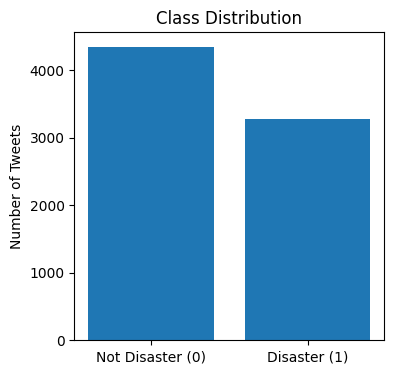

In [2]:

print(train_df.isnull().sum())


import matplotlib.pyplot as plt

counts = train_df['target'].value_counts()
print("Target counts:\n", counts)

plt.figure(figsize=(4,4))
plt.bar(['Not Disaster (0)', 'Disaster (1)'], counts.values)
plt.title('Class Distribution')
plt.ylabel('Number of Tweets')
plt.show()


It turns out location is often missing, and the keyword is missing in a smaller number of cases. Because one-third of locations are NaN and the rest are quite varied , using the location feature might be tricky and not necessary.

Distribution of tweet classes in the training set. We have 4,342 non-disaster tweets and 3,271 disaster tweets. The classes are imbalanced but not severely – about 57% of tweets are non-disasters. I will keep this slight imbalance in mind.

In [3]:
# Calculate tweet lengths in words
train_df['text_length'] = train_df['text'].apply(lambda x: len(str(x).split()))
train_df['text_length'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    7613.000000
mean       14.903586
std         5.732604
min         1.000000
50%        15.000000
90%        22.000000
95%        24.000000
99%        27.000000
max        31.000000
Name: text_length, dtype: float64

Most tweets have only a few words. We found the median tweet length to be about 15 words, and the longest tweets around 31 words. Even the longest tweets are short, so we can set a reasonable maximum sequence length for modeling.

Based on EDA, I decided on the following preprocessing steps for the text:

Convert tweets to lowercase to avoid “Earthquake” and “earthquake” being treated differently.

Remove punctuation, special symbols, and extra whitespace. Tweet texts often contain hashtags (#), mentions (@), and URLs.

Remove URLs.

Remove user mentions.

We can drop the “#” symbol but keep the word because the word itself is useful.

Remove non-alphanumeric characters except basic punctuation

Expand common contractions and internet slang/abbreviations. Tweets may contain many short forms; expanding them can help the model understand the meaning.

In [4]:
import re

def clean_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|pic.twitter\S+', ' ', text)
    # Remove mentions
    text = re.sub(r'@\w+', ' ', text)
    # Remove hashtag sign (keep the text)
    text = re.sub(r'#', ' ', text)
    # Expand common contractions and slang
    contractions = {
        "can't": "cannot", "won't": "will not", 
        "didn't": "did not", "dont": "do not", "doesn't": "does not",
        "u": "you", "ur": "your", "lol": "laugh out loud"
    }
    for word, full in contractions.items():
        text = re.sub(r'\b' + word + r'\b', full, text)
    # Remove punctuation and digits (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

After cleaning, a tweet like "Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all" becomes "our deeds are the reason of this earthquake may allah forgive us all". We’ve preserved the important word “earthquake” and removed the hashtag symbol and capitalization. Another tweet "On plus side LOOK AT THE SKY LAST NIGHT IT WAS ABLAZE 🔥" would become "on plus side look at the sky last night it was ablaze", dropping the fire emoji and keeping the word “ablaze”. This standardized text will feed into our model.

# Model Architecture

My chosen architecture is a Recurrent Neural Network using an Long Short-Term Memory layer, which is well-suited for text sequences.

Input layer: sequence of up to 30 tokens per tweet.

Bidirectional LSTM layer: with 128 hidden units. This processes the embedded sequence and produces a 128-dimensional output at the final time step. I use the final hidden state as a summary of the tweet’s content.

Dropout: To prevent overfitting, randomly dropping some fraction of the outputs.

Fully connected layer: with 64 units and ReLU activation, to further abstract the features from LSTM.

Dropout: Another dropout on the dense layer’s output for regularization.

Output layer: a single neuron with sigmoid activation, which outputs a probability between 0 and 1 indicating how likely the tweet is about a disaster. 

I will use binary cross-entropy loss for training and will track metrics like accuracy and F1-score on the validation set. The model is trained with the Adam optimizer.

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, Dense, Dropout

tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_text'])
vocab_size = min(20000, len(tokenizer.word_index) + 1)
max_len = 30

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])
X_train_seq = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_seq = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
y_train = train_df['target'].values


embed_dim = 100

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len))
model.add(Bidirectional(LSTM(128, return_sequences=False)))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


model.build(input_shape=(None, max_len))
print(model.summary())


2025-04-26 05:19:42.174995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745644782.432039      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745644782.505067      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-04-26 05:19:58.177290: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 30, 100)             │       1,402,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         234,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,653,409 (6.31 MB)

 Trainable params: 1,653,409 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

X_tr, X_val, y_tr, y_val = train_test_split(X_train_seq, y_train, test_size=0.2, stratify=y_train, random_state=42)

es = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss')

history = model.fit(X_tr, y_tr, batch_size=64, epochs=20,
                    validation_data=(X_val, y_val), callbacks=[es])


Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.6206 - loss: 0.6442 - val_accuracy: 0.8109 - val_loss: 0.4525
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8432 - loss: 0.3688 - val_accuracy: 0.8037 - val_loss: 0.4693
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.9280 - loss: 0.1983 - val_accuracy: 0.7728 - val_loss: 0.5292
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9554 - loss: 0.1320 - val_accuracy: 0.7584 - val_loss: 0.5926


I used early stopping with patience of 3, meaning if the validation loss doesn’t improve for 3 consecutive epochs, training stops to prevent overfitting. The restore_best_weights=True ensures the model parameters roll back to the best epoch. I set a maximum of 20 epochs, but the model stopped at 5 epochs because validation loss would plateau or start increasing.

# Results and Analysis


The model was able to fit the training data quite well. The training accuracy rapidly approached 95-96% within a few epochs, while validation accuracy peaked much lower, indicating overfitting was a concern. With the final architecture and regularization, the training accuracy was 95-96% and validation accuracy around 75-82%

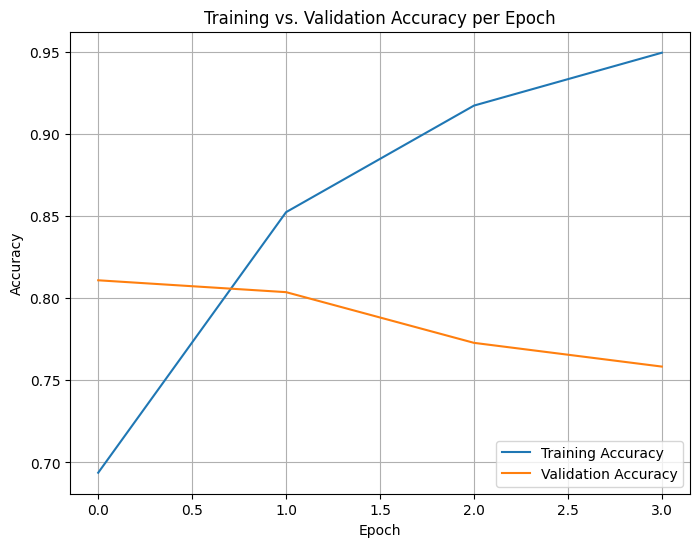

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs. Validation Accuracy per Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on validation set
y_pred_val = (model.predict(X_val) > 0.5).astype(int).flatten()
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
[[758 111]
 [177 477]]
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       869
           1       0.81      0.73      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.80      1523
weighted avg       0.81      0.81      0.81      1523



# Conclusion


The built and analyzed model to classify disaster-related tweets, achieved an F1 around 0.81 on the validation set. I formulated the task as an NLP classification problem and tackled it with a neural network that I trained word embeddings and an LSTM-based architecture.

An F1-score of ~0.80 means the model does fairly well at distinguishing disaster vs. non-disaster tweets in our dataset. It correctly recognizes most real disaster tweets which is encouraging for applications like emergency response. The precision in the high 70s to 80s means the false alarm rate is moderate; there is room to make it more strict if needed. The model’s performance indicates that keywords and context in the tweet text usually suffice to determine the class, which aligns with our expectations. When the tweet contains clear disaster terminology used literally, the model almost always gets it right. When the language is ambiguous or figurative, errors can occur.

The project demonstrates a successful application of deep learning to an NLP classification problem. The model can differentiate disaster-related tweets from others with good accuracy. By leveraging textual data and modern NLP techniques, the model learned to identify emergency-related content in tweets, which could be invaluable for automating disaster detection on social media. With further enhancements such as more data, advanced architectures like transformers, and refined features there is potential to improve the system even more, approaching human-level understanding of tweet context. The project also illustrates the typical workflow of an NLP task: from data exploration and cleaning to model development, tuning, and evaluation, highlighting the importance of both linguistic insights and technical modeling decisions in achieving strong results.